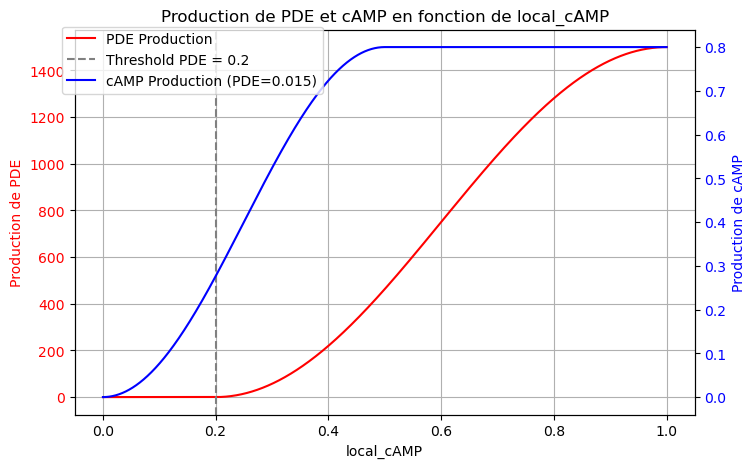

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres donnés
PDE_threshold = 0.2
PDE_rate = 1500.0
PDE_inhibition_threshold = 0.03
rho = 1e-9
alpha0 = 0.1
hill_n = 0.6
hill_K_h = 1

def compute_PDE_production(local_cAMP):
    """
    Calcule la production de PDE avec une activation sinusoïdale au lieu d'une sigmoïde.
    - La production reste nulle sous PDE_threshold.
    - Elle augmente en suivant une fonction sinusoïdale pour une transition plus douce.
    """
    if local_cAMP < PDE_threshold:
        return 0.0  # Aucune production en dessous du seuil
    
    # Normalisation entre 0 et 1 pour une transition douce
    normalized_cAMP = (local_cAMP - PDE_threshold) / (1 - PDE_threshold)  # Normalisé entre 0 et 1
    normalized_cAMP = min(max(normalized_cAMP, 0), 1)  # Clamping pour éviter dépassement
    
    # Application de la fonction sinusoïdale pour une montée douce
    sin_factor = np.sin(np.pi * normalized_cAMP / 2)**2  # Montée douce inspirée de sin²

    return PDE_rate * sin_factor  # Appliquer le facteur à la production

def compute_cAMP_production(local_cAMP, local_PDE):
    """
    Version modifiée de la production de cAMP avec une modulation sinusoïdale.
    - La sinusoïde atteint son maximum lorsque local_cAMP = 0.1.
    """
    cAMP_max = 0.5  # Valeur de local_cAMP où la production atteint son max
    
    if local_cAMP < cAMP_max:
        feedback = np.sin(np.pi * local_cAMP / (2 * cAMP_max))**2  # Décalage du max
    else:
        feedback = 1.0  # Saturation après le seuil

    inhibition = 1.0 /(1.0 + (local_PDE / PDE_inhibition_threshold)**2) if local_PDE > 0 else 1.0
    cAMP_production = rho * alpha0 + feedback
    return cAMP_production * inhibition

def plot_combined_production():
    """
    Trace les courbes de production de PDE et de cAMP sur un même graphique
    avec des échelles distinctes (axes Y gauche et droit).
    """
    # Plage de valeurs pour local_cAMP
    local_cAMP_values = np.linspace(0, 1, 5000)

    # Calcul des productions
    PDE_production_values = [compute_PDE_production(c) for c in local_cAMP_values]
    local_PDE = 0.015  # Fixe une valeur de PDE pour observer son effet sur la production de cAMP
    cAMP_production_values = [compute_cAMP_production(c, local_PDE) for c in local_cAMP_values]

    # Création du graphique avec deux axes Y
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Tracé de la production de PDE
    color_pde = 'red'
    ax1.set_xlabel("local_cAMP")
    ax1.set_ylabel("Production de PDE", color=color_pde)
    ax1.plot(local_cAMP_values, PDE_production_values, label="PDE Production", color=color_pde)
    ax1.tick_params(axis='y', labelcolor=color_pde)
    ax1.axvline(PDE_threshold, color='gray', linestyle='--', label=f"Threshold PDE = {PDE_threshold}")
    ax1.grid()

    # Second axe Y pour la production de cAMP
    ax2 = ax1.twinx()
    color_camp = 'blue'
    ax2.set_ylabel("Production de cAMP", color=color_camp)
    ax2.plot(local_cAMP_values, cAMP_production_values, label=f"cAMP Production (PDE={local_PDE})", color=color_camp)
    ax2.tick_params(axis='y', labelcolor=color_camp)

    # Ajout des légendes
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.title("Production de PDE et cAMP en fonction de local_cAMP")
    plt.show()

# Appel de la fonction pour tracer le graphique combiné
plot_combined_production()

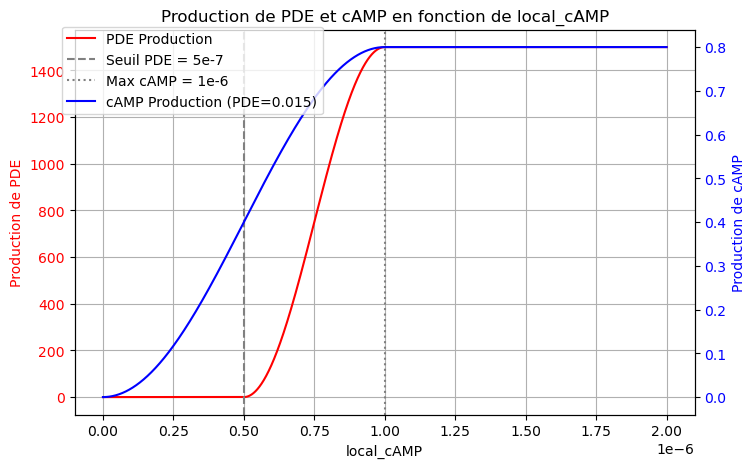

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres donnés
PDE_threshold = 5e-7         # Seuil en dessous duquel aucune production de PDE n'est déclenchée
PDE_rate = 1500.0
PDE_inhibition_threshold = 0.03
rho = 1e-9
alpha0 = 0.1
hill_n = 0.6
hill_K_h = 1

def compute_PDE_production(local_cAMP):
    """
    Calcule la production de PDE avec activation sinusoïdale pour une transition douce.
    - Pas de production si local_cAMP < 5e-7.
    - Entre 5e-7 et 1e-6, la production augmente progressivement.
    - Au-dessus de 1e-6, la production est saturée.
    """
    if local_cAMP < 5e-7:
        return 0.0  # Aucune production en dessous de 5e-7
    
    # Normalisation : 5e-7 correspond à 0, 1e-6 correspond à 1
    normalized_cAMP = (local_cAMP - 5e-7) / (1e-6 - 5e-7)
    normalized_cAMP = min(max(normalized_cAMP, 0), 1)  # Clamp entre 0 et 1
    
    # Activation sinusoïdale pour une montée douce (inspiration sin²)
    sin_factor = np.sin(np.pi * normalized_cAMP / 2)**2
    return PDE_rate * sin_factor


def compute_cAMP_production(local_cAMP, local_PDE):
    """
    Calcule la production de cAMP en modulant la rétroaction par une fonction sinusoïdale.
    - Le feedback atteint son maximum lorsque local_cAMP = 1e-6.
    """
    cAMP_max = 1e-6  # Le maximum du feedback est atteint à 1e-6
    
    if local_cAMP < cAMP_max:
        feedback = np.sin(np.pi * local_cAMP / (2 * cAMP_max))**2  
    else:
        feedback = 1.0  # Saturation au-delà de 1e-6
    
    # Inhibition par la PDE
    inhibition = 1.0 / (1.0 + (local_PDE / PDE_inhibition_threshold)**2) if local_PDE > 0 else 1.0
    cAMP_production = rho * alpha0 + feedback
    return cAMP_production * inhibition

def plot_combined_production():
    """
    Trace les courbes de production de PDE et de cAMP en fonction de local_cAMP,
    en couvrant une plage adaptée pour observer la montée et la saturation.
    """
    # Plage de valeurs pour local_cAMP de 0 à 2e-6 (pour couvrir 5e-7 à 1e-6)
    local_cAMP_values = np.linspace(0, 2e-6, 5000)

    # Calcul des productions
    PDE_production_values = [compute_PDE_production(c) for c in local_cAMP_values]
    local_PDE = 0.015  # Valeur fixe de PDE pour observer son effet dans la production de cAMP
    cAMP_production_values = [compute_cAMP_production(c, local_PDE) for c in local_cAMP_values]

    # Création du graphique avec deux axes Y
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Tracé de la production de PDE
    color_pde = 'red'
    ax1.set_xlabel("local_cAMP")
    ax1.set_ylabel("Production de PDE", color=color_pde)
    ax1.plot(local_cAMP_values, PDE_production_values, label="PDE Production", color=color_pde)
    ax1.tick_params(axis='y', labelcolor=color_pde)
    ax1.axvline(5e-7, color='gray', linestyle='--', label="Seuil PDE = 5e-7")
    ax1.axvline(1e-6, color='gray', linestyle=':', label="Max cAMP = 1e-6")
    ax1.grid()

    # Second axe Y pour la production de cAMP
    ax2 = ax1.twinx()
    color_camp = 'blue'
    ax2.set_ylabel("Production de cAMP", color=color_camp)
    ax2.plot(local_cAMP_values, cAMP_production_values, label=f"cAMP Production (PDE={local_PDE})", color=color_camp)
    ax2.tick_params(axis='y', labelcolor=color_camp)

    # Ajout des légendes
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.title("Production de PDE et cAMP en fonction de local_cAMP")
    plt.show()

# Appel de la fonction pour tracer le graphique combiné
plot_combined_production()

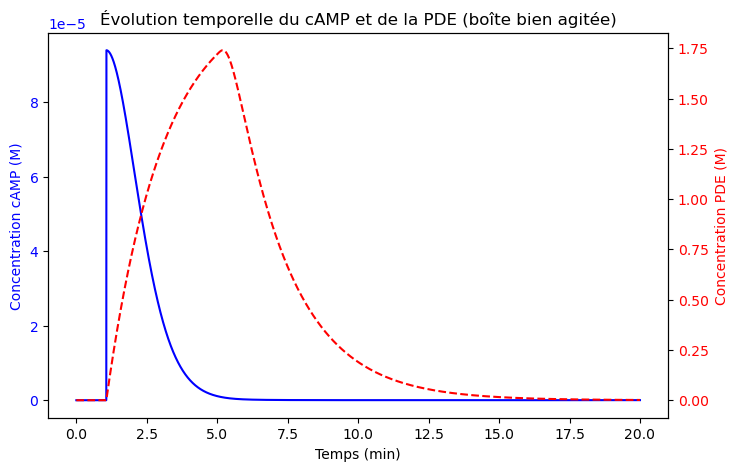

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# PARAMÈTRES DU MODÈLE
# ------------------------------
# Production et rétroaction
rho = 1e-5   # Production basale de cAMP (M/min)
alpha0 = 1.8e-6  # Facteur de rétroaction pour la production de cAMP
PDE_rate = 1.0   # Facteur de production de PDE
PDE_threshold = 1e-8  # Seuil cAMP pour production PDE
PDE_inhibition_threshold = 5e-6  # Seuil pour inhibition de PDE
k_PDE = 1.0   # Taux de dégradation du cAMP par la PDE (min^-1)
J = 0.01   # Taux de dégradation global du cAMP (min^-1)
PDE_decay = 0.4  # Dégradation naturelle de la PDE (min^-1)

rho = 5e-7   # Augmenter la production de cAMP
PDE_decay = 0.5  # Accélérer la disparition de la PDE
PDE_threshold = 5e-8  # Permettre au cAMP de monter plus haut avant d'activer la PDE
J = 0.005  # Réduire la dégradation globale du cAMP

# Paramètres temporels
dt = 0.001  # Pas de temps (min)
T_max = 20  # Durée de simulation (min)
n_steps = int(T_max / dt)  # Nombre de pas de temps

# ------------------------------
# FONCTIONS DE DYNAMIQUE
# ------------------------------
def compute_PDE_production(local_cAMP):
    """ Production de PDE en fonction du cAMP """
    if local_cAMP < PDE_threshold:
        return 0.0
    normalized_cAMP = (local_cAMP - PDE_threshold) / (1e-6 - PDE_threshold)
    normalized_cAMP = min(max(normalized_cAMP, 0), 1)
    sin_factor = np.sin(np.pi * normalized_cAMP / 2)**2
    return PDE_rate * sin_factor

def compute_cAMP_production(local_cAMP, local_PDE):
    """ Production de cAMP en fonction du local_cAMP et de l’inhibition PDE """
    cAMP_max = 1e-6  # Valeur où le feedback est maximal
    if local_cAMP < cAMP_max:
        feedback = np.sin(np.pi * local_cAMP / (2 * cAMP_max))**2
    else:
        feedback = 1.0
    inhibition = 1.0 / (1.0 + (local_PDE / PDE_inhibition_threshold)**2) if local_PDE > 0 else 1.0
    return (rho * alpha0 + feedback) * inhibition

# ------------------------------
# SIMULATION
# ------------------------------
# Initialisation
cAMP = np.zeros(n_steps)  # Concentration de cAMP
PDE = np.zeros(n_steps)   # Concentration de PDE
cAMP[0] = 1e-15  # Petite valeur initiale
PDE[0] = 0.0

# Boucle temporelle
for t in range(1, n_steps):
    local_cAMP = cAMP[t-1]
    local_PDE = PDE[t-1]

    # Calcul des productions
    cAMP_prod = compute_cAMP_production(local_cAMP, local_PDE)
    PDE_prod = compute_PDE_production(local_cAMP)

    # Mise à jour avec Euler explicite
    cAMP[t] = cAMP[t-1] + dt * (cAMP_prod - J * cAMP[t-1] - k_PDE * local_PDE * cAMP[t-1])
    PDE[t] = PDE[t-1] + dt * (PDE_prod - PDE_decay * PDE[t-1])

    # Éviter les valeurs négatives
    cAMP[t] = max(cAMP[t], 0)
    PDE[t] = max(PDE[t], 0)

# ------------------------------
# AFFICHAGE DES RÉSULTATS
# ------------------------------
time = np.linspace(0, T_max, n_steps)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Tracer le cAMP (échelle de gauche)
ax1.set_xlabel("Temps (min)")
ax1.set_ylabel("Concentration cAMP (M)", color="blue")
ax1.plot(time, cAMP, color="blue", label="cAMP")
ax1.tick_params(axis="y", labelcolor="blue")

# Tracer la PDE (échelle de droite)
ax2 = ax1.twinx()
ax2.set_ylabel("Concentration PDE (M)", color="red")
ax2.plot(time, PDE, color="red", linestyle="dashed", label="PDE")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Évolution temporelle du cAMP et de la PDE (boîte bien agitée)")
plt.show()

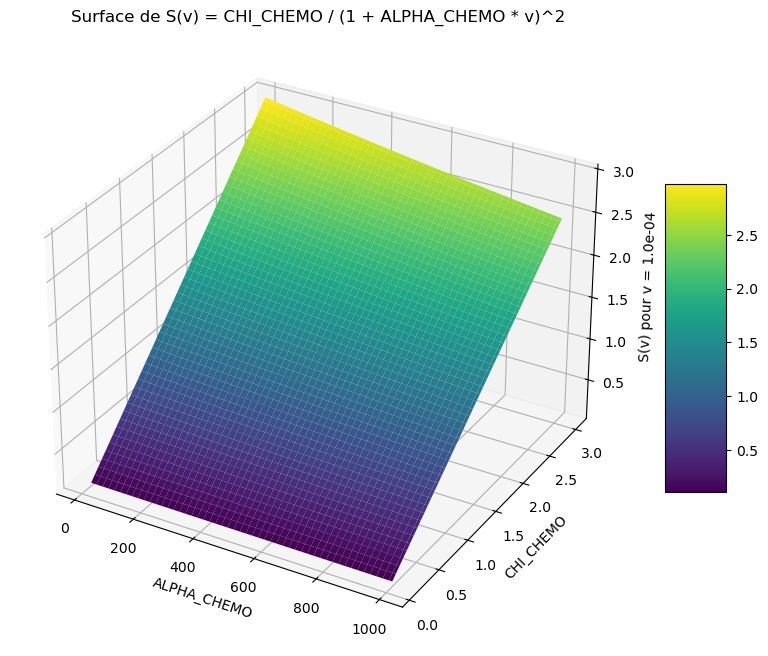

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import nécessaire pour le plot 3D

def plot_S_vs_alpha_chi(v=1e-4, alpha_range=(10, 1000), chi_range=(0.1, 3), num_points=100):
    """
    Trace la surface de S(v) = CHI_CHEMO / (1 + ALPHA_CHEMO * v)^2 en fonction de ALPHA_CHEMO et CHI_CHEMO.
    
    Args:
        v (float): Valeur fixe de la concentration (ex. 1e-4).
        alpha_range (tuple): Intervalle de valeurs pour ALPHA_CHEMO (min, max).
        chi_range (tuple): Intervalle de valeurs pour CHI_CHEMO (min, max).
        num_points (int): Nombre de points dans chaque dimension du maillage.
    """
    # Créer un maillage pour ALPHA_CHEMO et CHI_CHEMO
    alphas = np.linspace(alpha_range[0], alpha_range[1], num_points)
    chis = np.linspace(chi_range[0], chi_range[1], num_points)
    ALPHA, CHI = np.meshgrid(alphas, chis)
    
    # Calcul de S pour chaque couple (alpha, chi)
    S = CHI / (1 + ALPHA * v)**2
    
    # Création du plot 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(ALPHA, CHI, S, cmap='viridis', edgecolor='none')
    ax.set_xlabel('ALPHA_CHEMO')
    ax.set_ylabel('CHI_CHEMO')
    ax.set_zlabel('S(v) pour v = {:.1e}'.format(v))
    ax.set_title('Surface de S(v) = CHI_CHEMO / (1 + ALPHA_CHEMO * v)^2')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

# Exemple d'utilisation :
plot_S_vs_alpha_chi()

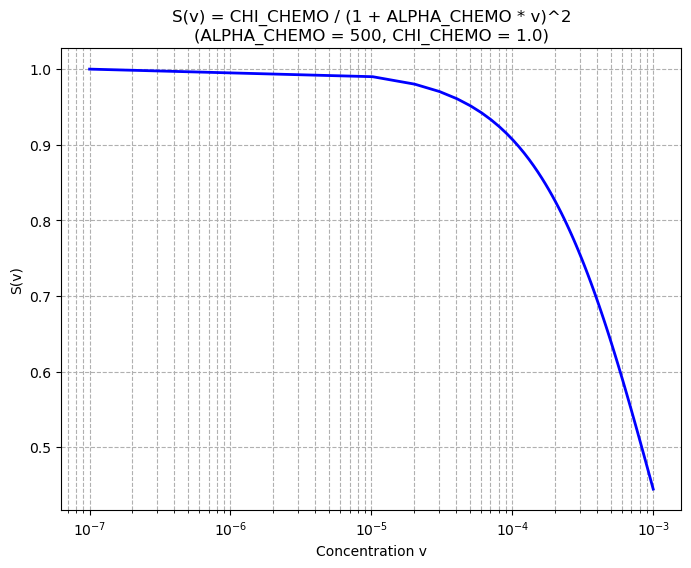

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_S_vs_v(v_range=(1e-7, 1e-3), ALPHA_CHEMO=500, CHI_CHEMO=1., num_points=100):
    """
    Trace S(v) = CHI_CHEMO / (1 + ALPHA_CHEMO * v)^2 en fonction de v
    pour v allant de v_range[0] à v_range[1].
    
    Args:
        v_range (tuple): Intervalle de valeurs pour v (par défaut de 1e-7 à 1e-3).
        ALPHA_CHEMO (float): Valeur fixe de ALPHA_CHEMO.
        CHI_CHEMO (float): Valeur fixe de CHI_CHEMO.
        num_points (int): Nombre de points pour le tracé.
    """
    # Générer une grille de valeurs pour v
    vs = np.linspace(v_range[0], v_range[1], num_points)
    # Calculer S(v) pour chaque valeur de v
    S = CHI_CHEMO / (1 + ALPHA_CHEMO * vs)**2

    # Création du graphique
    plt.figure(figsize=(8, 6))
    plt.plot(vs, S, '-b', linewidth=2)
    plt.xscale('log')  # Utilisation d'une échelle logarithmique pour v
    plt.xlabel('Concentration v')
    plt.ylabel('S(v)')
    plt.title('S(v) = CHI_CHEMO / (1 + ALPHA_CHEMO * v)^2\n(ALPHA_CHEMO = {}, CHI_CHEMO = {})'.format(ALPHA_CHEMO, CHI_CHEMO))
    plt.grid(True, which="both", ls="--")
    plt.show()

# Exemple d'utilisation :
plot_S_vs_v()